## Import dependincies

In [23]:
## Import dependencies
import os
import glob
import time
import copy

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import sys
sys.path.append("..")
from config import Config

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.0.1+cu118
CUDA available  : True
GPU             : NVIDIA GeForce GTX 1050


### Check config file

In [24]:
print(f"Device : {Config.DEVICE}")
print(f"Seed   : {Config.SEED}")

Device : cuda
Seed   : 42


## Data

### 1- Data Intialization

In [25]:
def load_data(data_dir: str):
    train_normal    = glob.glob(f"{data_dir}/train/NORMAL/*")
    train_pneumonia = glob.glob(f"{data_dir}/train/PNEUMONIA/*")
    test_normal     = glob.glob(f"{data_dir}/test/NORMAL/*")
    test_pneumonia  = glob.glob(f"{data_dir}/test/PNEUMONIA/*")

    train_paths  = train_normal + train_pneumonia
    test_paths   = test_normal  + test_pneumonia
    train_labels = [0] * len(train_normal)  + [1] * len(train_pneumonia)
    test_labels  = [0] * len(test_normal)   + [1] * len(test_pneumonia)

    print(f"Train — Normal: {len(train_normal):,} | Pneumonia: {len(train_pneumonia):,}")
    print(f"Test  — Normal: {len(test_normal):,}  | Pneumonia: {len(test_pneumonia):,}")

    return train_paths, test_paths, train_labels, test_labels


train_paths, test_paths, train_labels, test_labels = load_data(Config.DATA_DIR)

Train — Normal: 1,341 | Pneumonia: 3,875
Test  — Normal: 234  | Pneumonia: 390


### 2- Splitting 

In [26]:
# stratified split to keep class ratio in validation set
train_paths, valid_paths, train_labels, valid_labels = train_test_split(train_paths, train_labels,
                                                                        test_size=0.2,
                                                                        stratify=train_labels,
                                                                        random_state=Config.SEED)

print(f"\nTrain size : {len(train_paths):,}")
print(f"Val size   : {len(valid_paths):,}")
print(f"Test size  : {len(test_paths):,}")


Train size : 4,172
Val size   : 1,044
Test size  : 624


### 3- Transform

In [27]:
GRAY_MEAN = [0.5]
GRAY_STD  = [0.5]

train_transform = transforms.Compose([
    transforms.Resize(Config.IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=GRAY_MEAN, std=GRAY_STD)
])

test_transform = transforms.Compose([
    transforms.Resize(Config.IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=GRAY_MEAN, std=GRAY_STD)
])

### 4- Data loader

In [28]:
class XRayDataset(Dataset):
    """Custom PyTorch Dataset for chest X-ray images."""
    def __init__(self, paths: list, labels: list, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image = Image.open(self.paths[index]).convert("L")    # load image from and conert to luminance (grayscale)
        if self.transform:
            image = self.transform(image)                # apply transforms
        label = torch.tensor([self.labels[index]], dtype=torch.float32)    # load the labels and BCE expects float not int
        return image, label
    

train_data = XRayDataset(train_paths, train_labels, train_transform)
train_loader = DataLoader(train_data, batch_size= Config.BATCH_SIZE, shuffle = True) 


valid_data   = XRayDataset(valid_paths, valid_labels, test_transform)
valid_loader = DataLoader(valid_data, batch_size= Config.BATCH_SIZE, shuffle = False) 

## Model

In [29]:
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        # Block 1
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)  # 224x224 → 112x112
        
        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)  # 112x112 → 56x56
        
        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)  # 56x56 → 28x28
        
        # Fully connected
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.dropout = nn.Dropout(0.5)
        self.out = nn.Linear(256, num_classes)  # num_classes=1 for binar

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.out(x)

        return x

model = CNN(Config.IN_CHANNELS, Config.NUM_CLASSES).to(Config.DEVICE) 


### Loss & Optimizers

In [30]:
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr = Config.LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=Config.PATIENCE, factor=0.5, verbose=True) # reducing the learning rate

### Model Training

In [31]:
def train_model(
    model, criterion, optimizer, scheduler,
    train_loader, valid_loader,
    num_epochs: int, device: str, patience: int
):
    since          = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss  = float("inf")
    early_stop_ctr = 0
    history        = {"train_loss": [], "val_loss": [],
                      "train_acc":  [], "val_acc":  []}

    os.makedirs("models", exist_ok=True)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}  {'─' * 35}")

        # ── Training ──────────────────────────────────────────
        model.train()
        train_loss     = 0.0
        train_corrects = 0

        for inputs, labels in tqdm(train_loader, desc="  train", leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            preds   = outputs.sigmoid() > 0.5

            loss.backward()
            optimizer.step()

            train_loss     += loss.item() * inputs.size(0)
            train_corrects += torch.sum(preds == labels.bool())

        train_loss = train_loss / len(train_loader.dataset)
        train_acc  = train_corrects.double() / len(train_loader.dataset)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc.item())
        print(f"  train — Loss: {train_loss:.4f}  Acc: {train_acc:.4f}")

        # ── Validation ────────────────────────────────────────
        model.eval()
        val_loss     = 0.0
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in tqdm(valid_loader, desc="  val  ", leave=False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss    = criterion(outputs, labels)
                preds   = outputs.sigmoid() > 0.5

                val_loss     += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.bool())

        val_loss = val_loss / len(valid_loader.dataset)
        val_acc  = val_corrects.double() / len(valid_loader.dataset)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc.item())
        print(f"  val   — Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        # ── Scheduler, early stopping, checkpointing ──────────
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "models/cnn_best.pth")
            print(f"  ✅ Best model saved — Val Loss: {best_val_loss:.4f}")
            early_stop_ctr = 0
        else:
            early_stop_ctr += 1
            print(f"  ⚠️  No improvement ({early_stop_ctr}/{patience})")

        if early_stop_ctr >= patience:
            print("\n⛔ Early stopping triggered!")
            break

    model.load_state_dict(best_model_wts)
    elapsed = time.time() - since
    print(f"\nTraining complete — {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
    print(f"Best val loss : {best_val_loss:.4f}")
    return model, history

In [32]:
MODEL, history = train_model(model, criterion, optimizer, scheduler, 
                      train_loader, valid_loader, 
                      Config.NUM_EPOCHS, Config.DEVICE, Config.PATIENCE)


Epoch 1/15  ───────────────────────────────────


  train — Loss: 0.3616  Acc: 0.8382


  val   — Loss: 0.1877  Acc: 0.9320
  ✅ Best model saved — Val Loss: 0.1877

Epoch 2/15  ───────────────────────────────────


  train — Loss: 0.1983  Acc: 0.9235


  val   — Loss: 0.1782  Acc: 0.9262
  ✅ Best model saved — Val Loss: 0.1782

Epoch 3/15  ───────────────────────────────────


...

  val   — Loss: 0.0875  Acc: 0.9617
  ✅ Best model saved — Val Loss: 0.0875

Epoch 14/15  ───────────────────────────────────


  train — Loss: 0.1108  Acc: 0.9557


  val   — Loss: 0.0922  Acc: 0.9626
  ⚠️  No improvement (1/5)

Epoch 15/15  ───────────────────────────────────


  train — Loss: 0.1109  Acc: 0.9607


  val   — Loss: 0.0855  Acc: 0.9665
  ✅ Best model saved — Val Loss: 0.0855

Training complete — 27m 40s
Best val loss : 0.0855


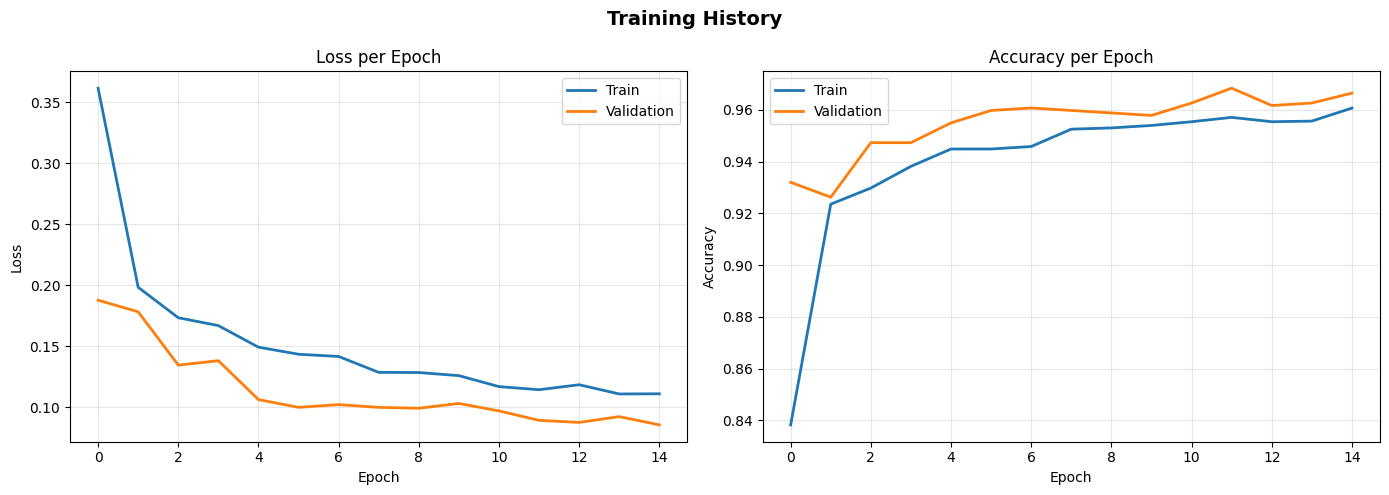

In [33]:
def plot_training_curves(history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training History", fontsize=14, fontweight="bold")

    for ax, metric, title, ylabel in zip(
        axes,
        [("train_loss", "val_loss"), ("train_acc", "val_acc")],
        ["Loss per Epoch", "Accuracy per Epoch"],
        ["Loss", "Accuracy"],
    ):
        ax.plot(history[metric[0]], label="Train", linewidth=2)
        ax.plot(history[metric[1]], label="Validation", linewidth=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(history)

## Model Evaluation

Evaluating: 100%|██████████| 20/20 [00:06<00:00,  3.01it/s]


              precision    recall  f1-score   support

      Normal       0.95      0.35      0.52       234
   Pneumonia       0.72      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.84      0.67      0.67       624
weighted avg       0.81      0.75      0.71       624

Accuracy : 0.7516
F1 Score : 0.8328


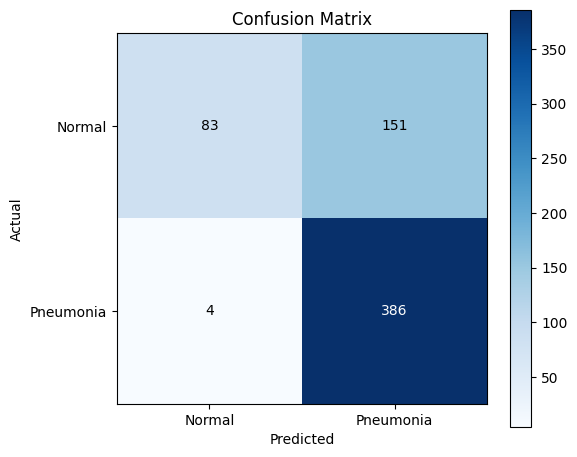

In [36]:
## Evaluation
# ── Load test data ────────────────────────────────────────────────────────────
test_data   = XRayDataset(test_paths, test_labels, test_transform)
test_loader = DataLoader(test_data, batch_size=Config.BATCH_SIZE, shuffle=False)

# ── Run inference ─────────────────────────────────────────────────────────────
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluating"):
        inputs  = inputs.to(Config.DEVICE)
        outputs = model(inputs)
        preds   = outputs.sigmoid() > 0.5

        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

# ── Metrics ───────────────────────────────────────────────────────────────────
print(classification_report(all_labels, all_preds, target_names=["Normal", "Pneumonia"]))

print(f"Accuracy : {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score : {f1_score(all_labels, all_preds):.4f}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)

ax.set_xticks([0, 1]); ax.set_xticklabels(["Normal", "Pneumonia"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "Pneumonia"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()